# HighRes-Net Training on Microscopy Data

This notebook trains HighRes-Net on your TIFF microscopy dataset (7 LR frames → 2x HR upsampling).

**Format:**
- ✓ TIFF 8-bit grayscale files (LR_1.tif/tiff through LR_7.tif/tiff + HR.tif/tiff per image)
- ✓ Pre-augmented images in D:\GUC\Datasets\HighRes input test\image_0000\, image_0001\, etc.
- ✓ 2x upsampling (128×128 LR → 256×256 HR)
- ✓ Supports both .tif and .tiff extensions (identical format)
- ✓ GPU acceleration with RTX 4060

## 1. Setup and Imports

In [1]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import time

sys.path.insert(0, '../src')

import torch
import torch.optim as optim
from torch.utils.data import DataLoader

from DataLoader import TiffPatchDataset, collateFunction
from DeepNetworks.HRNet import HRNet

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch Version: 2.7.1+cu118
CUDA Available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Memory: 8.59 GB


## 2. Verify Dataset

In [2]:
data_root = Path("D:\\GUC\\Datasets\\HighRes input test")
image_dirs = sorted([d for d in data_root.iterdir() if d.is_dir() and d.name.startswith("image_")])

print(f"✓ Found {len(image_dirs)} images")

# Verify first image has required files
if image_dirs:
    first = image_dirs[0]
    lr_files = sorted(first.glob("LR_*.tif*"))
    hr_file = list(first.glob("HR.tif*"))
    print(f"✓ Sample ({first.name}): {len(lr_files)} LR frames, {len(hr_file)} HR frame")

✓ Found 247 images
✓ Sample (image_0000): 7 LR frames, 1 HR frame


## 3. Load Configuration

In [3]:
config_path = Path('../config/config.json')
with open(config_path, 'r') as f:
    config = json.load(f)

print("Training Configuration:")
print(f"  Num epochs: {config['training']['num_epochs']}")
print(f"  Batch size: {config['training']['batch_size']}")
print(f"  Learning rate: {config['training']['lr']}")
print(f"  Patch size: {config['training']['patch_size']}")
print(f"  N_views: {config['training']['n_views']}")
print(f"  Create patches: {config['training']['create_patches']}")

Training Configuration:
  Num epochs: 30
  Batch size: 8
  Learning rate: 0.0003
  Patch size: 128
  N_views: 7
  Create patches: False


## 5. Create Datasets and DataLoaders

In [4]:
print("Creating TIFF dataset...")

# Discover all image directories
data_root = Path("D:\\GUC\\Datasets\\HighRes input test")
image_dirs = sorted([str(d) for d in data_root.iterdir() if d.is_dir() and d.name.startswith("image_")])

print(f"Discovered {len(image_dirs)} images")

# Create dataset from images
train_dataset = TiffPatchDataset(
    patch_dirs=image_dirs,
    max_views=config['training']['n_views']
)

print(f"Training dataset size: {len(train_dataset)} images")

# Create DataLoader
batch_size = config['training']['batch_size']
min_L = config['training']['min_L']

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=collateFunction(min_L=min_L),
    pin_memory=torch.cuda.is_available()
)

print(f"DataLoader created:")
print(f"  batch_size: {batch_size}")
print(f"  num_batches: {len(train_loader)}")
print(f"  pin_memory: {torch.cuda.is_available()}")

Creating TIFF dataset...
Discovered 247 images
Training dataset size: 247 images
DataLoader created:
  batch_size: 8
  num_batches: 31
  pin_memory: True


## 6. Initialize Model

In [5]:
print("Initializing model...")

model = HRNet(config['network'])
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Model device: {device}")

Initializing model...
Model parameters: 620,490
Model device: cuda


## 7. Setup Optimizer and Loss

In [6]:
print("Setting up training...")

criterion = torch.nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=config['training']['lr'],
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=config['training']['lr_step'],
    gamma=config['training']['lr_decay']
)

print(f"Optimizer: Adam")
print(f"  Learning rate: {config['training']['lr']}")
print(f"  LR decay: {config['training']['lr_decay']} every {config['training']['lr_step']} epochs")
print(f"Loss function: MSELoss")

Setting up training...
Optimizer: Adam
  Learning rate: 0.0003
  LR decay: 0.95 every 3 epochs
Loss function: MSELoss


## 8. Training Loop

In [7]:
# Weight versioning helpers (safe undo/rollback workflow)
import shutil
from datetime import datetime
from pathlib import Path

weights_dir = Path("../models/weights")
checkpoints_dir = weights_dir / "checkpoints"
backups_dir = weights_dir / "backups"
best_weights_path = weights_dir / "HRNet.pth"

checkpoints_dir.mkdir(parents=True, exist_ok=True)
backups_dir.mkdir(parents=True, exist_ok=True)

def list_weight_versions():
    candidates = []
    if best_weights_path.exists():
        candidates.append(best_weights_path)
    candidates.extend(sorted(checkpoints_dir.glob("checkpoint_epoch_*.pth"), key=lambda p: p.stat().st_mtime, reverse=True))
    candidates.extend(sorted(backups_dir.glob("HRNet_backup_*.pth"), key=lambda p: p.stat().st_mtime, reverse=True))

    if not candidates:
        print("No weight files found.")
        return

    print("Available weight versions (newest first):")
    for p in candidates:
        ts = datetime.fromtimestamp(p.stat().st_mtime).strftime("%Y-%m-%d %H:%M:%S")
        print(f"  - {p.name:35s}  {p.stat().st_size/1e6:7.2f} MB  {ts}")

def create_manual_backup(tag="manual"):
    if not best_weights_path.exists():
        print(f"No current best file at {best_weights_path}; nothing to back up.")
        return None

    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    backup_path = backups_dir / f"HRNet_backup_{tag}_{stamp}.pth"
    shutil.copy2(best_weights_path, backup_path)
    print(f"Backup created: {backup_path}")
    return backup_path

def restore_weights_from(path_or_name):
    path_or_name = str(path_or_name)
    candidate = Path(path_or_name)

    if not candidate.exists():
        # Try resolving by filename inside known folders
        for base in [weights_dir, checkpoints_dir, backups_dir]:
            probe = base / path_or_name
            if probe.exists():
                candidate = probe
                break

    if not candidate.exists():
        raise FileNotFoundError(f"Could not find weights file: {path_or_name}")

    shutil.copy2(candidate, best_weights_path)
    print(f"Restored {candidate} -> {best_weights_path}")
    return best_weights_path

print("Weight versioning helpers loaded.")
list_weight_versions()
#restore_weights_from("checkpoint_epoch_200.pth")

Weight versioning helpers loaded.
Available weight versions (newest first):
  - HRNet.pth                               2.49 MB  2026-04-20 02:38:58
  - checkpoint_epoch_25.pth                 2.49 MB  2026-04-20 22:03:47
  - checkpoint_epoch_200.pth                2.49 MB  2026-04-20 00:05:50
  - checkpoint_epoch_175.pth                2.49 MB  2026-04-20 00:00:21
  - checkpoint_epoch_150.pth                2.49 MB  2026-04-19 23:54:46
  - checkpoint_epoch_125.pth                2.49 MB  2026-04-19 23:49:00
  - checkpoint_epoch_100.pth                2.49 MB  2026-04-19 23:42:48
  - checkpoint_epoch_75.pth                 2.49 MB  2026-04-19 23:37:06
  - checkpoint_epoch_50.pth                 2.49 MB  2026-04-19 23:31:27


In [8]:
from tqdm import tqdm
import json as json_module
import sys
import shutil
from datetime import datetime

# ============================================================================
# Range + smoothness regularizers
# ============================================================================
def compute_range_loss(sr_output, hr_target):
    """
    Prevent output dynamic-range collapse by matching SR/HR range statistics.
    """
    sr_min = sr_output.min()
    sr_max = sr_output.max()
    sr_range = sr_max - sr_min

    hr_min = hr_target.min()
    hr_max = hr_target.max()

    target_range = 0.6
    range_loss = (sr_range - target_range) ** 2
    min_align = (sr_min - hr_min) ** 2
    max_align = (sr_max - hr_max) ** 2
    return range_loss * 0.5 + (min_align + max_align) * 0.25


def tv_loss(output):
    """Standard TV: penalizes all local variation (can oversmooth edges)."""
    diff_h = torch.abs(output[:, :, 1:, :] - output[:, :, :-1, :])
    diff_w = torch.abs(output[:, :, :, 1:] - output[:, :, :, :-1])
    return torch.mean(diff_h) + torch.mean(diff_w)


def edge_aware_tv_loss(output, hr_target, edge_k=10.0):
    """
    Penalize SR variation mostly where HR is smooth, and relax penalty at true HR edges.
    """
    hr_grad_h = torch.abs(hr_target[:, :, 1:, :] - hr_target[:, :, :-1, :])
    hr_grad_w = torch.abs(hr_target[:, :, :, 1:] - hr_target[:, :, :, :-1])

    edge_weight_h = torch.exp(-edge_k * hr_grad_h)
    edge_weight_w = torch.exp(-edge_k * hr_grad_w)

    sr_grad_h = torch.abs(output[:, :, 1:, :] - output[:, :, :-1, :])
    sr_grad_w = torch.abs(output[:, :, :, 1:] - output[:, :, :, :-1])

    return torch.mean(edge_weight_h * sr_grad_h) + torch.mean(edge_weight_w * sr_grad_w)


def _radial_frequency_mask(h, w, low_ratio, high_ratio, device, dtype):
    """Build a radial band-pass mask in normalized FFT frequency radius [0, 1]."""
    fy = torch.fft.fftfreq(h, d=1.0, device=device).view(h, 1)
    fx = torch.fft.fftfreq(w, d=1.0, device=device).view(1, w)
    r = torch.sqrt(fy * fy + fx * fx)
    r = r / r.max().clamp_min(1e-8)
    mask = ((r >= low_ratio) & (r <= high_ratio)).to(dtype)
    return mask


def freq_band_loss(sr_output, hr_target, low_ratio=0.08, high_ratio=0.35, use_log_magnitude=True):
    """
    Penalize spectral error energy in a selected mid-frequency band.
    This is more targeted than spatial TV for ringing suppression.
    """
    # Error spectrum focuses regularization on reconstruction residuals.
    err = sr_output - hr_target
    err_fft = torch.fft.fft2(err, dim=(-2, -1))
    err_mag = torch.abs(err_fft)

    if use_log_magnitude:
        err_mag = torch.log1p(err_mag)

    h = err_mag.shape[-2]
    w = err_mag.shape[-1]
    band = _radial_frequency_mask(h, w, low_ratio, high_ratio, err_mag.device, err_mag.dtype)
    band = band.unsqueeze(0).unsqueeze(0)

    # Normalize by active band size to keep scale stable across resolutions.
    denom = band.sum() * err_mag.shape[0] * err_mag.shape[1]
    return ((err_mag * band) ** 2).sum() / denom.clamp_min(1.0)


print("\nStarting training with configurable composite loss...")
print("=" * 70)
print("Loss = MSE + lambda_range * RangeLoss + lambda_smooth * SmoothnessLoss")
print("SmoothnessLoss mode: none | tv | edge_aware_tv | freq_band")
print("=" * 70)

num_epochs = config['training']['num_epochs']
lambda_range = config['training'].get('lambda_range', 0.003)

# Backward-compatible smoothness config
smoothness_mode = config['training'].get('smoothness_mode', 'tv').lower()
lambda_tv = config['training'].get('lambda_tv', 0.0)
lambda_edge_tv = config['training'].get('lambda_edge_tv', 0.0)
lambda_freq = config['training'].get('lambda_freq', 0.0)
edge_aware_k = float(config['training'].get('edge_aware_k', 10.0))
freq_low_ratio = float(config['training'].get('freq_low_ratio', 0.08))
freq_high_ratio = float(config['training'].get('freq_high_ratio', 0.35))
freq_use_log_magnitude = bool(config['training'].get('freq_use_log_magnitude', True))

if smoothness_mode == 'edge_aware_tv':
    lambda_smooth = lambda_edge_tv if lambda_edge_tv > 0 else lambda_tv
elif smoothness_mode == 'tv':
    lambda_smooth = lambda_tv
elif smoothness_mode == 'freq_band':
    lambda_smooth = lambda_freq
else:
    lambda_smooth = 0.0

best_loss = float('inf')
best_weights_path = Path("../models/weights/HRNet.pth")
best_weights_path.parent.mkdir(parents=True, exist_ok=True)

# Automatic pre-train snapshot for one-click undo
backups_dir = best_weights_path.parent / "backups"
backups_dir.mkdir(exist_ok=True)
if best_weights_path.exists():
    snapshot_name = f"HRNet_backup_pretrain_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
    snapshot_path = backups_dir / snapshot_name
    shutil.copy2(best_weights_path, snapshot_path)
    print(f"Pre-train backup created: {snapshot_path}")
else:
    print("No existing HRNet.pth found; skipping pre-train backup.")

print(f"lambda_range:            {lambda_range}")
print(f"smoothness_mode:         {smoothness_mode}")
print(f"lambda_smooth:           {lambda_smooth}")
print(f"edge_aware_k:            {edge_aware_k}")
print(f"freq_low/high ratios:    {freq_low_ratio} / {freq_high_ratio}")
print(f"freq_use_log_magnitude:  {freq_use_log_magnitude}\n")

checkpoint_meta_path = best_weights_path.parent / "training_metadata.json"
checkpoint_dir = best_weights_path.parent / "checkpoints"
checkpoint_dir.mkdir(exist_ok=True)

train_losses = []
train_mse_losses = []
train_range_losses = []
train_tv_losses = []
train_edge_tv_losses = []
train_freq_losses = []
epoch_times = []

resume_epoch = 0
if checkpoint_meta_path.exists():
    with open(checkpoint_meta_path, 'r') as f:
        meta = json_module.load(f)
        resume_epoch = meta.get('last_saved_epoch', 0)
        best_loss = meta.get('best_loss', float('inf'))
        print(f"Resuming from epoch {resume_epoch}")
        print(f"Previous best loss: {best_loss:.6f}\n")

pbar = tqdm(
    range(1, num_epochs + 1),
    desc="Training",
    unit="epoch",
    file=sys.stdout,
    ncols=100,
    disable=False,
    bar_format='{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]'
 )

for epoch in pbar:
    epoch_start = time.time()

    model.train()
    batch_losses = []
    batch_mse_losses = []
    batch_range_losses = []
    batch_tv_losses = []
    batch_edge_tv_losses = []
    batch_freq_losses = []

    for batch_idx, (lrs, alphas, hrs, hr_maps, names) in enumerate(train_loader):
        lrs = lrs.float().to(device)
        alphas = alphas.float().to(device)
        hrs = hrs.float().to(device)

        sr_output = model(lrs, alphas)

        if epoch == 1 and batch_idx == 0:
            print("\nShape check:")
            print(f"  LR input shape: {lrs.shape}")
            print(f"  SR output shape: {sr_output.shape}")
            print(f"  HR target shape: {hrs.shape}")

        mse_loss = criterion(sr_output, hrs)
        range_loss = compute_range_loss(sr_output, hrs)
        tv_reg = tv_loss(sr_output)
        edge_tv_reg = edge_aware_tv_loss(sr_output, hrs, edge_k=edge_aware_k)
        freq_reg = freq_band_loss(
            sr_output,
            hrs,
            low_ratio=freq_low_ratio,
            high_ratio=freq_high_ratio,
            use_log_magnitude=freq_use_log_magnitude,
        )

        if smoothness_mode == 'edge_aware_tv':
            smooth_loss = edge_tv_reg
        elif smoothness_mode == 'tv':
            smooth_loss = tv_reg
        elif smoothness_mode == 'freq_band':
            smooth_loss = freq_reg
        else:
            smooth_loss = torch.zeros_like(mse_loss)

        loss = mse_loss + lambda_range * range_loss + lambda_smooth * smooth_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        batch_mse_losses.append(mse_loss.item())
        batch_range_losses.append(range_loss.item())
        batch_tv_losses.append(tv_reg.item())
        batch_edge_tv_losses.append(edge_tv_reg.item())
        batch_freq_losses.append(freq_reg.item())

    epoch_loss = np.mean(batch_losses)
    epoch_mse_loss = np.mean(batch_mse_losses)
    epoch_range_loss = np.mean(batch_range_losses)
    epoch_tv_loss = np.mean(batch_tv_losses)
    epoch_edge_tv_loss = np.mean(batch_edge_tv_losses)
    epoch_freq_loss = np.mean(batch_freq_losses)

    train_losses.append(epoch_loss)
    train_mse_losses.append(epoch_mse_loss)
    train_range_losses.append(epoch_range_loss)
    train_tv_losses.append(epoch_tv_loss)
    train_edge_tv_losses.append(epoch_edge_tv_loss)
    train_freq_losses.append(epoch_freq_loss)

    scheduler.step()

    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    pbar.set_postfix({
        'loss': f'{epoch_loss:.6f}',
        'mse': f'{epoch_mse_loss:.6f}',
        'range': f'{epoch_range_loss:.4f}',
        'tv': f'{epoch_tv_loss:.4f}',
        'e_tv': f'{epoch_edge_tv_loss:.4f}',
        'freq': f'{epoch_freq_loss:.4f}',
        'time': f'{epoch_time:.1f}s'
    })

    sys.stdout.flush()

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), best_weights_path)
        pbar.write(f"  Best loss updated at epoch {epoch}")

    if epoch % 25 == 0:
        checkpoint_path = checkpoint_dir / f"checkpoint_epoch_{epoch}.pth"
        torch.save(model.state_dict(), checkpoint_path)
        pbar.write(f"  Checkpoint saved: epoch_{epoch}.pth")

    if epoch % 10 == 0:
        meta = {
            'last_saved_epoch': epoch,
            'best_loss': float(best_loss),
            'current_loss': float(epoch_loss),
            'current_mse': float(epoch_mse_loss),
            'current_range': float(epoch_range_loss),
            'current_tv': float(epoch_tv_loss),
            'current_edge_tv': float(epoch_edge_tv_loss),
            'current_freq': float(epoch_freq_loss),
            'smoothness_mode': smoothness_mode,
            'lambda_smooth': float(lambda_smooth),
            'edge_aware_k': float(edge_aware_k),
            'freq_low_ratio': float(freq_low_ratio),
            'freq_high_ratio': float(freq_high_ratio),
            'freq_use_log_magnitude': bool(freq_use_log_magnitude),
            'num_epochs': num_epochs,
            'dataset_size': len(train_dataset),
            'timestamp': time.time()
        }
        with open(checkpoint_meta_path, 'w') as f:
            json_module.dump(meta, f, indent=2)

pbar.close()

print("\n" + "=" * 70)
print("Training complete")
print(f"Best combined loss: {best_loss:.6f}")
print(f"Weights saved to: {best_weights_path}")
print(f"Checkpoint metadata: {checkpoint_meta_path}")
print(f"Periodic checkpoints in: {checkpoint_dir}")
print("\nTraining Statistics:")
print(f"  Total time: {sum(epoch_times) / 60:.1f} minutes")
print(f"  Avg time per epoch: {np.mean(epoch_times):.1f}s")
print("\nMSE Loss (pixel accuracy):")
print(f"  Initial: {train_mse_losses[0]:.6f}")
print(f"  Final:   {train_mse_losses[-1]:.6f}")
print(f"  Improvement: {(train_mse_losses[0] - train_mse_losses[-1]) / train_mse_losses[0] * 100:.1f}%")
print("\nRange Loss (dynamic range):")
print(f"  Initial: {train_range_losses[0]:.6f}")
print(f"  Final:   {train_range_losses[-1]:.6f}")
print(f"  Improvement: {(train_range_losses[0] - train_range_losses[-1]) / train_range_losses[0] * 100:.1f}%")
print("\nSmoothness diagnostics:")
print(f"  TV initial/final:       {train_tv_losses[0]:.6f} -> {train_tv_losses[-1]:.6f}")
print(f"  Edge-TV initial/final:  {train_edge_tv_losses[0]:.6f} -> {train_edge_tv_losses[-1]:.6f}")
print(f"  Freq initial/final:     {train_freq_losses[0]:.6f} -> {train_freq_losses[-1]:.6f}")
print(f"  Active smoothness mode: {smoothness_mode} (lambda={lambda_smooth})")
print("=" * 70)


Starting training with configurable composite loss...
Loss = MSE + lambda_range * RangeLoss + lambda_smooth * SmoothnessLoss
SmoothnessLoss mode: none | tv | edge_aware_tv | freq_band
Pre-train backup created: ..\models\weights\backups\HRNet_backup_pretrain_20260420_220923.pth
lambda_range:            0.003
smoothness_mode:         freq_band
lambda_smooth:           0.01
edge_aware_k:            10.0
freq_low/high ratios:    0.12 / 0.28
freq_use_log_magnitude:  True

Training:   0%|                                                                     | 0/30 [00:00<?]
Shape check:
  LR input shape: torch.Size([8, 7, 128, 128])
  SR output shape: torch.Size([8, 1, 256, 256])
  HR target shape: torch.Size([8, 1, 256, 256])
  Best loss updated at epoch 1                                                                      
  Best loss updated at epoch 2                                                                      
  Best loss updated at epoch 3                                      

In [9]:


import os
from pathlib import Path

print("="*70)
print("FINE-TUNING SETUP")
print("="*70)

metadata_path = Path("../models/weights/training_metadata.json")
weights_path = Path("../models/weights/HRNet.pth")

print("\n📋 Current State:")
print(f"  Weights file exists: {weights_path.exists()}")
print(f"  Metadata file exists: {metadata_path.exists()}")

# Delete ONLY metadata (allows fresh 350-epoch cycle)
if metadata_path.exists():
    os.remove(metadata_path)
    print(f"\n✓ Deleted metadata (removes 'resume from epoch X')")
else:
    print(f"\n  Metadata already deleted or never created")

# Verify weights still exist for fine-tuning
if weights_path.exists():
    print(f"✓ Weights preserved (will use as initialization)")
    print(f"\n🎯 FINE-TUNING MODE READY:")
    print(f"   Old weights: Will initialize this training")
    print(f"   Fresh cycle: 350 epochs on circles data")
    print(f"   Expected: Specialize to circle recognition")
else:
    print(f"\n⚠️  Weights file missing! Training from RANDOM initialization")
    print(f"   This is fine but you lose previous progress.")
    print(f"   Make sure you meant to restart from scratch.")

print("\n" + "="*70)
print("Ready to start fine-tuning training. Run cell 8 next.\n")


FINE-TUNING SETUP

📋 Current State:
  Weights file exists: True
  Metadata file exists: True

✓ Deleted metadata (removes 'resume from epoch X')
✓ Weights preserved (will use as initialization)

🎯 FINE-TUNING MODE READY:
   Old weights: Will initialize this training
   Fresh cycle: 350 epochs on circles data
   Expected: Specialize to circle recognition

Ready to start fine-tuning training. Run cell 8 next.



## 9. Plot Training Curve

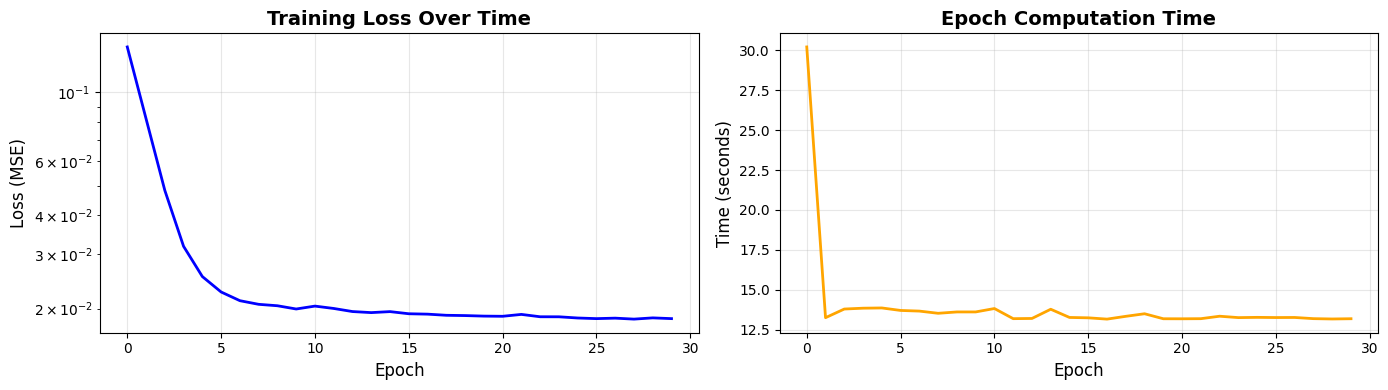


Training Statistics:
  Total time: 7.0 minutes
  Avg time per epoch: 14.0s
  Loss decreased by: 86.8%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Training loss
axes[0].plot(train_losses, linewidth=2, color='blue')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Epoch time
axes[1].plot(epoch_times, linewidth=2, color='orange')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Time (seconds)', fontsize=12)
axes[1].set_title('Epoch Computation Time', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining Statistics:")
print(f"  Total time: {sum(epoch_times)/60:.1f} minutes")
print(f"  Avg time per epoch: {np.mean(epoch_times):.1f}s")
print(f"  Loss decreased by: {(train_losses[0] - train_losses[-1]) / train_losses[0] * 100:.1f}%")

## 10. Test Trained Model

In [11]:
# Optional: load a specific historical checkpoint before testing/inference
from pathlib import Path
import torch

weights_dir = Path("../models/weights")
checkpoint_dir = weights_dir / "checkpoints"
best_weights_path = weights_dir / "HRNet.pth"

# Set to an integer epoch from periodic checkpoints (e.g., 50, 75, 100, 125, 150, 175, 200)
# Set to None to use HRNet.pth
target_epoch = None

if target_epoch is None:
    selected_weights = best_weights_path
else:
    selected_weights = checkpoint_dir / f"checkpoint_epoch_{target_epoch}.pth"

if not selected_weights.exists():
    available = sorted([p.name for p in checkpoint_dir.glob("checkpoint_epoch_*.pth")])
    raise FileNotFoundError(
        f"Selected checkpoint not found: {selected_weights}\nAvailable: {available}"
    )

state_dict = torch.load(selected_weights, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f"Loaded weights from: {selected_weights}")

Loaded weights from: ..\models\weights\HRNet.pth


In [12]:
print("Testing trained model...\n")

# Uses weights already loaded in previous cell. If that cell was skipped, fallback to HRNet.pth
if 'selected_weights' not in globals():
    selected_weights = Path("../models/weights/HRNet.pth")
    model.load_state_dict(torch.load(selected_weights, map_location=device))
    model.eval()
    print(f"Loaded fallback weights: {selected_weights}")
else:
    print(f"Using preloaded weights: {selected_weights}")

# Get test batch
test_batch = next(iter(train_loader))
test_lrs, test_alphas, test_hrs, test_hr_maps, test_names = test_batch

test_lrs = test_lrs.float().to(device)
test_alphas = test_alphas.float().to(device)

# Forward pass
with torch.no_grad():
    test_sr = model(test_lrs, test_alphas)

print(f"✓ Test inference passed!")
print(f"  Input (LR):  {test_lrs.shape}")
print(f"  Output (SR): {test_sr.shape}")
print(f"  Output range: [{test_sr.min():.4f}, {test_sr.max():.4f}]")

print(f"\n✓ Active weights: {selected_weights}")
print(f"\nNext steps:")
print(f"  1. Run inference_diagnostic.ipynb to evaluate quality")
print(f"  2. Check PSNR/SSIM metrics vs bicubic baseline")
print(f"  3. If quality still low, train for more epochs or with more data")

Testing trained model...

Using preloaded weights: ..\models\weights\HRNet.pth
✓ Test inference passed!
  Input (LR):  torch.Size([8, 7, 128, 128])
  Output (SR): torch.Size([8, 1, 256, 256])
  Output range: [0.0676, 0.9898]

✓ Active weights: ..\models\weights\HRNet.pth

Next steps:
  1. Run inference_diagnostic.ipynb to evaluate quality
  2. Check PSNR/SSIM metrics vs bicubic baseline
  3. If quality still low, train for more epochs or with more data
